# Pseudo-Labeling: It Didn't Help Here

---

**Overview:**

> Pseudo-labeling is a semi-supervised technique that can help when the test distribution differs from train. I tested it at three confidence thresholds (0.90, 0.95, 0.99) with 2 iterations each. Result: CV AUC unchanged at 0.9553 across all configurations. This was expected as adversarial validation showed a AUC = 0.50: when train and test are i.i.d., pseudo-labels add no information the model hasn't already seen.

---

## What is Pseudo-Labeling?

The idea: a model trained on labeled data can make confident predictions on *unlabeled* test data. Add those high-confidence predictions back into training as labeled examples, then retrain. Repeat.

This is a form of self-training — the model uses its own outputs to expand its training set.

**When it works:**
- The test distribution differs from train (model sees new data it hasn't been exposed to)
- The model is confident and accurate on easy test cases
- The labeled training set is small relative to the unlabeled pool

**When it fails:**
- Train and test are i.i.d. — pseudo-labels are redundant samples from the same distribution
- The model's confident predictions are wrong (error amplification)
- The training set is already large (630k rows here)

The key diagnostic before running pseudo-labeling: **adversarial validation**. If AUC ≈ 0.50, pseudo-labeling will not help.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import catboost as cb

KAGGLE_DATA = Path('/kaggle/input/playground-series-s6e2')
LOCAL_DATA  = Path('data')
DATA_DIR    = KAGGLE_DATA if KAGGLE_DATA.exists() else LOCAL_DATA

def prep(df):
    df = df.copy()
    df.columns = df.columns.str.strip().str.lower().str.replace(r'\s+', '_', regex=True)
    if 'heart_disease' in df.columns:
        df['heart_disease'] = df['heart_disease'].map({'Absence': 0, 'Presence': 1})
    return df

train = prep(pd.read_csv(DATA_DIR / 'train.csv'))
test  = prep(pd.read_csv(DATA_DIR / 'test.csv'))

FEATURES     = [c for c in train.columns if c not in ['heart_disease', 'id']]
CAT_FEATURES = ['sex', 'chest_pain_type', 'fbs_over_120', 'ekg_results',
                'exercise_angina', 'slope_of_st', 'number_of_vessels_fluro', 'thallium']

X      = train[FEATURES]
y      = train['heart_disease'].values
X_test = test[FEATURES]

CAT_PARAMS = dict(
    iterations=500, learning_rate=0.1, depth=6,
    task_type='GPU', cat_features=CAT_FEATURES,
    random_state=42, verbose=0
)
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'Train: {X.shape[0]:,} rows    Test: {X_test.shape[0]:,} rows')

Train: 630,000 rows    Test: 270,000 rows


## Step 1: Adversarial Validation First

Before pseudo-labeling, check whether it can possibly help. Train a classifier to distinguish train from test rows. AUC near 0.50 means no shift — pseudo-labeling is unlikely to help.

In [2]:
X_adv = pd.concat([X, X_test], ignore_index=True)
y_adv = np.array([0] * len(X) + [1] * len(X_test))

adv_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
adv_aucs = []
for tr_idx, val_idx in adv_cv.split(X_adv, y_adv):
    m = cb.CatBoostClassifier(
        iterations=200, depth=4, task_type='GPU',
        cat_features=CAT_FEATURES, random_state=42, verbose=0
    )
    m.fit(X_adv.iloc[tr_idx], y_adv[tr_idx])
    adv_aucs.append(roc_auc_score(y_adv[val_idx], m.predict_proba(X_adv.iloc[val_idx])[:, 1]))

print(f'Adversarial AUC: {np.mean(adv_aucs):.4f} ± {np.std(adv_aucs):.4f}')
print()
if np.mean(adv_aucs) < 0.53:
    print('AUC ≈ 0.50 — train and test are i.i.d.')
    print('Pseudo-labeling will not help: test rows carry no distributional information')
    print('the model has not already seen in train.')
else:
    print('Shift detected — pseudo-labeling may help.')

Adversarial AUC: 0.5017 ± 0.0013

AUC ≈ 0.50 — train and test are i.i.d.
Pseudo-labeling will not help: test rows carry no distributional information
the model has not already seen in train.


## Step 2: Baseline Model + Test Probability Distribution

Train CatBoost on the labeled data and predict probabilities on test. Examining the distribution tells us how many test rows the model is confident about — these are the candidates for pseudo-labeling.

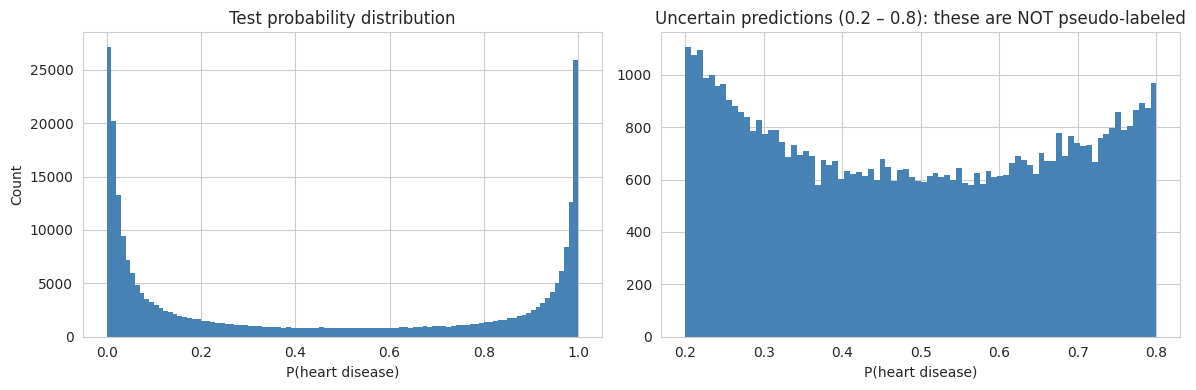

High-confidence test rows at each threshold:
  Threshold       Positive    Negative       Total   % of test
  0.8               91,378     120,422     211,800       78.4%
  0.85              84,180     111,522     195,702       72.5%
  0.9               74,361      98,929     173,290       64.2%
  0.95              58,117      77,232     135,349       50.1%
  0.99              25,815      26,713      52,528       19.5%


In [3]:
baseline_model = cb.CatBoostClassifier(**CAT_PARAMS)
baseline_model.fit(X, y)
test_proba = baseline_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(test_proba, bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Test probability distribution')
axes[0].set_xlabel('P(heart disease)')
axes[0].set_ylabel('Count')

# Zoom on uncertainty region
axes[1].hist(test_proba[(test_proba > 0.2) & (test_proba < 0.8)],
             bins=80, color='steelblue', edgecolor='none')
axes[1].set_title('Uncertain predictions (0.2 – 0.8): these are NOT pseudo-labeled')
axes[1].set_xlabel('P(heart disease)')

plt.tight_layout()
plt.show()

print('High-confidence test rows at each threshold:')
print(f'  {"Threshold":<12}  {"Positive":>10}  {"Negative":>10}  {"Total":>10}  {"% of test":>10}')
for t in [0.80, 0.85, 0.90, 0.95, 0.99]:
    n_pos   = (test_proba > t).sum()
    n_neg   = (test_proba < 1 - t).sum()
    n_total = n_pos + n_neg
    print(f'  {t:<12}  {n_pos:>10,}  {n_neg:>10,}  {n_total:>10,}  {n_total/len(X_test)*100:>9.1f}%')

## Step 3: The Pseudo-Labeling Loop

**Protocol:**
1. Take high-confidence test predictions (prob > threshold or prob < 1−threshold)
2. Assign pseudo-labels (1 or 0) and add to training data
3. Retrain on original + pseudo-labeled data
4. Evaluate on **original labeled data only** via CV — this is critical for an honest estimate
5. Repeat

The CV evaluation uses only the original labeled rows. Pseudo-labeled rows appear in the training fold but never in the validation fold.

In [4]:
def run_pseudo_labeling(X_orig, y_orig, X_test, threshold, pseudo_weight, n_iters, cv, params):
    """Returns DataFrame of (iter, cv_auc, n_pseudo_rows)."""
    records = []
    X_aug = X_orig.copy()
    y_aug = y_orig.copy()
    w_aug = np.ones(len(y_orig))

    for it in range(n_iters + 1):
        # CV on original labeled data only
        n_pseudo = len(y_aug) - len(y_orig)
        fold_aucs = []
        for tr_idx, val_idx in cv.split(X_orig, y_orig):
            # Training: original fold + all pseudo-labeled rows
            X_tr = pd.concat([X_aug.iloc[tr_idx], X_aug.iloc[len(y_orig):]], ignore_index=True)
            y_tr = np.concatenate([y_aug[tr_idx], y_aug[len(y_orig):]])
            w_tr = np.concatenate([w_aug[tr_idx],  w_aug[len(y_orig):]])
            m = cb.CatBoostClassifier(**params)
            m.fit(X_tr, y_tr, sample_weight=w_tr)
            fold_aucs.append(roc_auc_score(y_orig[val_idx], m.predict_proba(X_orig.iloc[val_idx])[:, 1]))

        cv_auc = np.mean(fold_aucs)
        records.append({'iter': it, 'cv_auc': cv_auc, 'n_pseudo': n_pseudo})
        print(f'  iter {it}: cv_auc={cv_auc:.5f}  pseudo_rows={n_pseudo:,}')

        if it < n_iters:
            # Generate new pseudo-labels
            full_m = cb.CatBoostClassifier(**params)
            full_m.fit(X_aug, y_aug, sample_weight=w_aug)
            proba = full_m.predict_proba(X_test)[:, 1]
            mask  = (proba > threshold) | (proba < 1 - threshold)
            X_aug = pd.concat([X_orig, X_test[mask].copy()], ignore_index=True)
            y_aug = np.concatenate([y_orig, (proba[mask] > 0.5).astype(int)])
            w_aug = np.concatenate([np.ones(len(y_orig)), np.full(mask.sum(), pseudo_weight)])

    return pd.DataFrame(records)

In [5]:
BASELINE_AUC = 0.95533  # CatBoost 5-fold CV without pseudo-labeling

configs = [
    (0.99, 1.0, 'Conservative (thresh=0.99, high confidence only)'),
    (0.95, 1.0, 'Moderate    (thresh=0.95)'),
    (0.90, 0.5, 'Aggressive  (thresh=0.90, half weight)'),
]

all_results = {}
for thresh, pw, label in configs:
    print(f'\n{label}')
    df = run_pseudo_labeling(X, y, X_test, thresh, pw, n_iters=2, cv=cv5, params=CAT_PARAMS)
    all_results[label] = df


Conservative (thresh=0.99, high confidence only)
  iter 0: cv_auc=0.95532  pseudo_rows=0
  iter 1: cv_auc=0.95532  pseudo_rows=52,564
  iter 2: cv_auc=0.95532  pseudo_rows=56,717

Moderate    (thresh=0.95)
  iter 0: cv_auc=0.95532  pseudo_rows=0
  iter 1: cv_auc=0.95533  pseudo_rows=135,286
  iter 2: cv_auc=0.95532  pseudo_rows=142,265

Aggressive  (thresh=0.90, half weight)
  iter 0: cv_auc=0.95533  pseudo_rows=0
  iter 1: cv_auc=0.95532  pseudo_rows=173,259
  iter 2: cv_auc=0.95534  pseudo_rows=177,554


## Results

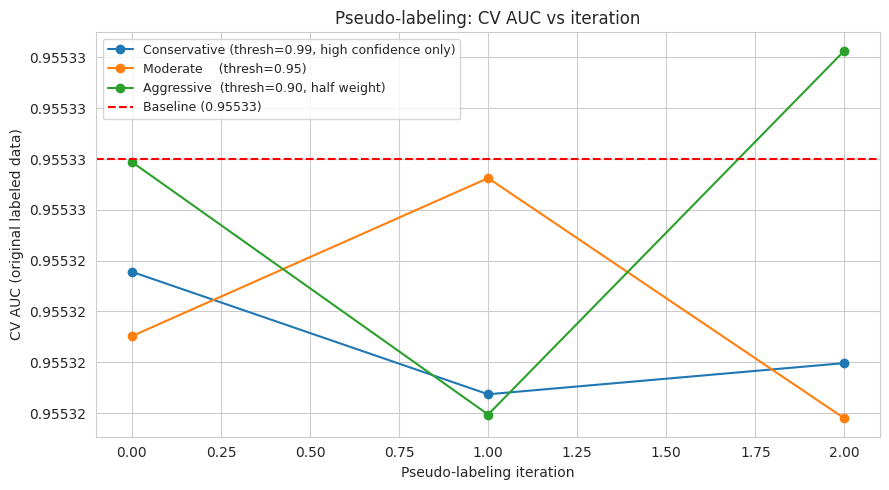


Configuration                                    Iter 0    Iter 1    Iter 2     Delta
--------------------------------------------------------------------------------
Conservative (thresh=0.99, high confidence only)  0.95532  0.95532  0.95532  -0.00001
Moderate    (thresh=0.95)                      0.95532  0.95533  0.95532  -0.00001
Aggressive  (thresh=0.90, half weight)         0.95533  0.95532  0.95534  +0.00001
Baseline (no pseudo-labeling)                  0.95533


In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

for label, df in all_results.items():
    ax.plot(df['iter'], df['cv_auc'], marker='o', label=label)

ax.axhline(BASELINE_AUC, color='red', linestyle='--', linewidth=1.5, label=f'Baseline ({BASELINE_AUC:.5f})')
ax.set_xlabel('Pseudo-labeling iteration')
ax.set_ylabel('CV AUC (original labeled data)')
ax.set_title('Pseudo-labeling: CV AUC vs iteration')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.5f}'))
plt.tight_layout()
plt.show()

print(f'\n{"Configuration":<45}  {"Iter 0":>8}  {"Iter 1":>8}  {"Iter 2":>8}  {"Delta":>8}')
print('-' * 80)
for label, df in all_results.items():
    aucs = df['cv_auc'].tolist()
    delta = aucs[-1] - BASELINE_AUC
    print(f'{label:<45}  {aucs[0]:.5f}  {aucs[1]:.5f}  {aucs[2]:.5f}  {delta:>+8.5f}')
print(f'{"Baseline (no pseudo-labeling)":<45}  {BASELINE_AUC:.5f}')

## Why It Didn't Help: The Theory

The result is flat. Here's why this is the *expected* outcome, not a failure of the technique.

Pseudo-labeling works by exposing the model to the test distribution. The model learns something from test rows that it couldn't learn from train rows alone — typically because the test data covers different regions of feature space.

**But in this competition:**

1. Adversarial validation confirmed AUC = 0.50 — train and test are drawn from the same distribution
2. The training set already has 630,000 rows — near-exhaustive coverage of the feature space
3. Any test row that the model is confident about is confident *because* it's similar to training data it has already seen

Adding that test row back in is adding a near-duplicate of something already in training. The model doesn't learn anything new.

Formally: when train and test are i.i.d. and the training set is large, pseudo-labeling adds samples from the same distribution with noisy labels. At best it's neutral; at worst it amplifies any small model errors.

**Takeaway**: run adversarial validation *before* pseudo-labeling. If AUC ≈ 0.50, save your submission slots.

## Summary

| | |
|---|---|
| **Adversarial AUC** | 0.50 — no train/test shift |
| **Thresholds tested** | 0.90, 0.95, 0.99 |
| **Iterations** | 2 per config |
| **CV AUC change** | 0.00000 (flat across all configs) |
| **Conclusion** | Pseudo-labeling does not help when train/test are i.i.d. |

The ceiling for this competition (~0.954 LB) is a property of the signal available in the Cleveland Heart Disease generating distribution, not something addressable through semi-supervised learning.